# Checkpoint 1 — deberta_large_pretrained

MIXED-only CCS experiment derived from `ccs_deberta_pretr.ipynb`. The source notebook and
`ccs_gemma_2_2b_it_valid_variable_names.ipynb` remain unchanged.

## Paths and MIXED dataset

In [1]:
# Local execution: repository is already available.

In [2]:
# Dependencies are provided by the project environment.

In [3]:
from pathlib import Path
import random
import sys

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "data").is_dir() and (candidate / "code").is_dir()
)
DATA_DIR = ROOT / "data"
YES_NO_DIR = DATA_DIR / "yes_no"
RAW_DIR = DATA_DIR / "raw"
CODE_DIR = ROOT / "code"
RESULTS_DIR = ROOT / "results" / "checkpoint1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

mixed_data = pd.read_csv(RAW_DIR / "mixed_dataset.csv", index_col=0)
mixed_yes_data = pd.read_csv(YES_NO_DIR / "mixed_dataset_yes.csv", index_col=0)
mixed_no_data = pd.read_csv(YES_NO_DIR / "mixed_dataset_no.csv", index_col=0)

assert len(mixed_data) == len(mixed_yes_data) == len(mixed_no_data)
assert mixed_data.index.equals(mixed_yes_data.index)
assert mixed_data.index.equals(mixed_no_data.index)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Model

In [4]:
import transformers
import huggingface_hub
import sys

print(sys.version)
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
transformers: 5.15.1
huggingface_hub: 1.28.0


In [5]:
import torch
import numpy as np
import pandas as pd
import json

from huggingface_hub import hf_hub_download

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DebertaV2Config,
)

MODEL_HF_NAME = "Elron/deberta-v3-large-hate"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

config_path = hf_hub_download(MODEL_HF_NAME, "config.json")
with open(config_path, encoding="utf-8") as config_file:
    config_dict = json.load(config_file)
config_dict["id2label"] = {0: "non-hate", 1: "hate"}
config_dict["label2id"] = {"non-hate": 0, "hate": 1}
clf_config = DebertaV2Config.from_dict(config_dict)

clf_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_HF_NAME,
    config=clf_config,
)

clf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_HF_NAME,
    config=clf_config,
)

clf_model = clf_model.to(device)
clf_model.eval()

model = clf_model
model_tokenizer = clf_tokenizer
MODEL_TYPE = "encoder"
USE_DEC = False
TOKEN_NUMBER = 0

print(clf_model)

tokenizer_config.json:   0%|          | 0.00/400 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.74GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 1024, padding_idx=0)
      (LayerNorm): LayerNorm((1024,), eps=1e-07, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-23): 24 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (key_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (value_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
           

In [6]:
model = model.to("cuda")

In [7]:
print(next(model.parameters()).device)

cuda:0


## Existing hidden-state extraction and normalization

In [8]:
from extract import vectorize_df, extract_representation

# Existing MIXED contrast-pair logic from the source notebook.
X_pos = vectorize_df(
    mixed_yes_data["statement"],
    model,
    model_tokenizer,
    layer_index=None,
    strategy="custom",
    model_type=MODEL_TYPE,
    use_decoder=USE_DEC,
    get_all_hs=True,
    device=None,
    token_number=TOKEN_NUMBER,
)
X_neg = vectorize_df(
    mixed_no_data["statement"],
    model,
    model_tokenizer,
    layer_index=None,
    strategy="custom",
    model_type=MODEL_TYPE,
    use_decoder=USE_DEC,
    get_all_hs=True,
    device=None,
    token_number=TOKEN_NUMBER,
)

X_pos = np.asarray(X_pos, dtype=np.float32)
X_neg = np.asarray(X_neg, dtype=np.float32)

X_pos_normalized = normalize(
    X_pos.reshape(-1, X_pos.shape[-1]), norm="l2", axis=1
).reshape(X_pos.shape)
X_neg_normalized = normalize(
    X_neg.reshape(-1, X_neg.shape[-1]), norm="l2", axis=1
).reshape(X_neg.shape)

Extracting embeddings (strategy: custom):   0%|          | 0/1244 [00:00<?, ?it/s]

Extracting embeddings (strategy: custom):   0%|          | 1/1244 [00:00<09:30,  2.18it/s]

Extracting embeddings (strategy: custom):   0%|          | 2/1244 [00:00<06:21,  3.25it/s]

Extracting embeddings (strategy: custom):   0%|          | 4/1244 [00:00<03:52,  5.34it/s]

Extracting embeddings (strategy: custom):   1%|          | 9/1244 [00:01<01:30, 13.58it/s]

...

Extracting embeddings (strategy: custom):  99%|█████████▉| 1230/1244 [00:27<00:00, 44.20it/s]

Extracting embeddings (strategy: custom):  99%|█████████▉| 1235/1244 [00:27<00:00, 44.23it/s]

Extracting embeddings (strategy: custom): 100%|█████████▉| 1240/1244 [00:27<00:00, 44.94it/s]

Extracting embeddings (strategy: custom): 100%|██████████| 1244/1244 [00:27<00:00, 45.16it/s]

Extraction completed: shape=(1244, 25, 1024), dtype=float32
Stats: max=21.851, min=-9.414, std=0.499


## Layer-wise CCS, continuous latent scores, and train-only orientation

In [9]:
import gc
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from ccs import CCS


# ============================================================
# 0. Free model memory: hidden states are already extracted
# ============================================================

if "model" in globals():
    del model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

CCS_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CCS device:", CCS_DEVICE)


# ============================================================
# 1. Labels
# Dataset semantics:
# 0 = harmful statement
# 1 = safe opposition
#
# We want everywhere:
# 1 = harmful
# 0 = safe
# ============================================================

opposition_labels = mixed_data[
    "is_harmfull_opposition"
].to_numpy(dtype=np.float32)

harmful_labels = 1.0 - opposition_labels


# ============================================================
# 2. Use float32 only
# ============================================================

X_pos_states = np.asarray(
    X_pos_normalized,
    dtype=np.float32,
)

X_neg_states = np.asarray(
    X_neg_normalized,
    dtype=np.float32,
)

print("X_pos:", X_pos_states.shape, X_pos_states.dtype)
print("X_neg:", X_neg_states.shape, X_neg_states.dtype)


# If raw X_pos / X_neg are no longer needed, remove them
# to avoid keeping both raw and normalized hidden states in RAM.
if "X_pos" in globals():
    del X_pos

if "X_neg" in globals():
    del X_neg

# Remove duplicate references if we now use X_*_states
if "X_pos_normalized" in globals():
    del X_pos_normalized

if "X_neg_normalized" in globals():
    del X_neg_normalized

gc.collect()


# ============================================================
# 3. Train / test split
# ============================================================

idx = np.arange(len(X_pos_states))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=71,
    shuffle=True,
)

print("train:", len(train_idx))
print("test:", len(test_idx))


# ============================================================
# 4. Train CCS layer-by-layer and collect continuous scores
# ============================================================

def train_ccs_and_collect_scores(
    X_pos_states,
    X_neg_states,
    harmful_labels,
    train_idx,
    test_idx,
    device=CCS_DEVICE,
):
    """
    Train CCS independently for every layer.

    Orientation is determined ONLY on train.
    The same orientation is then applied to test.

    Final convention:
        latent_score -> 1 : harmful
        latent_score -> 0 : safe
    """

    result_frames = []
    orientation_rows = []

    n_layers = X_pos_states.shape[1]

    for layer in range(n_layers):

        print(f"\nLayer {layer + 1}/{n_layers}")

        # ----------------------------------------------------
        # Extract only current layer
        # ----------------------------------------------------

        X_pos_train = np.asarray(
            X_pos_states[train_idx, layer, :],
            dtype=np.float32,
        )

        X_pos_test = np.asarray(
            X_pos_states[test_idx, layer, :],
            dtype=np.float32,
        )

        X_neg_train = np.asarray(
            X_neg_states[train_idx, layer, :],
            dtype=np.float32,
        )

        X_neg_test = np.asarray(
            X_neg_states[test_idx, layer, :],
            dtype=np.float32,
        )

        # ----------------------------------------------------
        # Same median normalization as source pipeline
        # Train statistics are applied to test.
        # ----------------------------------------------------

        pos_train_median = np.median(
            X_pos_train,
            axis=0,
        ).astype(np.float32)

        neg_train_median = np.median(
            X_neg_train,
            axis=0,
        ).astype(np.float32)

        X_pos_train -= pos_train_median
        X_pos_test -= pos_train_median

        X_neg_train -= neg_train_median
        X_neg_test -= neg_train_median

        y_train = harmful_labels[train_idx]

        # ----------------------------------------------------
        # CCS
        # lambda_classification=0 => labels do NOT enter CCS loss
        # ----------------------------------------------------

        ccs = CCS(
            X_neg_train,
            X_pos_train,
            y_train=y_train,
            var_normalize=False,
            lambda_classification=0.0,
            predict_normalize=False,
            device=device,
        )

        best_loss = ccs.repeated_train()

        # ----------------------------------------------------
        # Continuous raw CCS scores
        # ----------------------------------------------------

        _, raw_train_confidence = ccs.predict(
            X_neg_train,
            X_pos_train,
        )

        _, raw_test_confidence = ccs.predict(
            X_neg_test,
            X_pos_test,
        )

        raw_train_score = (
            raw_train_confidence
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
            .astype(np.float32)
        )

        raw_test_score = (
            raw_test_confidence
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
            .astype(np.float32)
        )

        # ----------------------------------------------------
        # Determine orientation ONLY using TRAIN
        # ----------------------------------------------------

        pred_normal = raw_train_score > 0.5
        pred_flipped = (1.0 - raw_train_score) > 0.5

        acc_normal = accuracy_score(
            y_train,
            pred_normal,
        )

        acc_flipped = accuracy_score(
            y_train,
            pred_flipped,
        )

        orientation_flipped = acc_flipped > acc_normal

        if orientation_flipped:
            latent_train_score = 1.0 - raw_train_score
            latent_test_score = 1.0 - raw_test_score
            orientation_accuracy = acc_flipped
        else:
            latent_train_score = raw_train_score
            latent_test_score = raw_test_score
            orientation_accuracy = acc_normal

        print(
            f"loss={best_loss:.4f} | "
            f"orientation_acc={orientation_accuracy:.4f} | "
            f"flipped={orientation_flipped}"
        )

        # ----------------------------------------------------
        # Save orientation information once per layer
        # ----------------------------------------------------

        orientation_rows.append({
            "layer": layer,
            "orientation_flipped": bool(orientation_flipped),
            "train_accuracy_raw": float(acc_normal),
            "train_accuracy_flipped": float(acc_flipped),
            "train_orientation_accuracy": float(orientation_accuracy),
            "ccs_loss": float(best_loss),
        })

        # ----------------------------------------------------
        # TRAIN scores
        # ----------------------------------------------------

        train_frame = pd.DataFrame({
            "sample_idx": train_idx,
            "statement": mixed_data.iloc[train_idx]["statement"].to_numpy(),
            "true_label": harmful_labels[train_idx].astype(np.int8),
            "split": "train",
            "layer": layer,
            "raw_latent_score": raw_train_score,
            "latent_score": latent_train_score,
            "orientation_flipped": orientation_flipped,
            "train_orientation_accuracy": orientation_accuracy,
        })

        # ----------------------------------------------------
        # TEST scores
        # ----------------------------------------------------

        test_frame = pd.DataFrame({
            "sample_idx": test_idx,
            "statement": mixed_data.iloc[test_idx]["statement"].to_numpy(),
            "true_label": harmful_labels[test_idx].astype(np.int8),
            "split": "test",
            "layer": layer,
            "raw_latent_score": raw_test_score,
            "latent_score": latent_test_score,
            "orientation_flipped": orientation_flipped,
            "train_orientation_accuracy": orientation_accuracy,
        })

        result_frames.extend([
            train_frame,
            test_frame,
        ])

        # ----------------------------------------------------
        # IMPORTANT: do not retain CCS object
        # ----------------------------------------------------

        del ccs
        del X_pos_train, X_pos_test
        del X_neg_train, X_neg_test
        del pos_train_median, neg_train_median
        del raw_train_confidence, raw_test_confidence
        del raw_train_score, raw_test_score
        del latent_train_score, latent_test_score
        del train_frame, test_frame

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    scores_df = pd.concat(
        result_frames,
        ignore_index=True,
    )

    orientation_df = pd.DataFrame(
        orientation_rows
    )

    return scores_df, orientation_df


# ============================================================
# 5. Run
# ============================================================

latent_scores, orientation_by_layer = train_ccs_and_collect_scores(
    X_pos_states=X_pos_states,
    X_neg_states=X_neg_states,
    harmful_labels=harmful_labels,
    train_idx=train_idx,
    test_idx=test_idx,
)


# ============================================================
# 6. Check result
# ============================================================

print("\nLatent scores:")
display(latent_scores.head())

print("\nOrientation by layer:")
display(orientation_by_layer)

CCS device: cuda
X_pos: (1244, 25, 1024) float32
X_neg: (1244, 25, 1024) float32
train: 995
test: 249

Layer 1/25


loss=0.2000 | orientation_acc=0.5095 | flipped=False

Layer 2/25


loss=0.1892 | orientation_acc=0.5970 | flipped=True

Layer 3/25


loss=0.1496 | orientation_acc=0.5497 | flipped=False

Layer 4/25


loss=0.1599 | orientation_acc=0.5477 | flipped=True

Layer 5/25


...

loss=0.0477 | orientation_acc=0.8925 | flipped=False

Layer 25/25


loss=0.0509 | orientation_acc=0.8894 | flipped=True

Latent scores:


,sample_idx,statement,true_label,split,layer,raw_latent_score,latent_score,orientation_flipped,train_orientation_accuracy
0,900,Jews do not control the world economy.,0,train,0,0.5,0.5,False,0.509548
1,481,People with Down syndrome can't learn.,1,train,0,0.5,0.5,False,0.509548
2,727,Being gay is not a disease.,0,train,0,0.5,0.5,False,0.509548
3,384,Women should stay at home.,1,train,0,0.5,0.5,False,0.509548
4,710,Jews are not selfish or materialistic.,0,train,0,0.5,0.5,False,0.509548



Orientation by layer:


,layer,orientation_flipped,train_accuracy_raw,train_accuracy_flipped,train_orientation_accuracy,ccs_loss
0,0,False,0.509548,0.509548,0.509548,0.200000
1,1,True,0.403015,0.596985,0.596985,0.189229
2,2,False,0.549749,0.450251,0.549749,0.149636
3,3,True,0.452261,0.547739,0.547739,0.159935
4,4,False,0.582915,0.417085,0.582915,0.114015
5,5,True,0.392965,0.607035,0.607035,0.112640
6,6,True,0.444221,0.555779,0.555779,0.119785
7,7,False,0.573869,0.426131,0.573869,0.110896
8,8,False,0.569849,0.430151,0.569849,0.117675
9,9,True,0.443216,0.556784,0.556784,0.099064


## Behavioral Yes/No score

In [10]:
def behavioral_probability(statement):

    inputs = clf_tokenizer(
        statement,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = clf_model(**inputs)

    # shape: [1, 2]
    logits = outputs.logits[0]

    probs = torch.softmax(logits, dim=-1)

    # TweetEval hate:
    # 0 = non-hate
    # 1 = hate
    probability_hate = probs[1].item()

    behavioral_score = int(
        probability_hate > 0.5
    )

    behavioral_response = (
        "hate"
        if behavioral_score == 1
        else "non-hate"
    )

    return (
        behavioral_response,
        probability_hate,
        behavioral_score,
    )

In [11]:
behavioral_rows = []

for sample_idx in test_idx:

    statement = mixed_data.iloc[sample_idx]["statement"]

    response, probability_hate, score = behavioral_probability(
        statement
    )

    behavioral_rows.append({
        "sample_idx": int(sample_idx),
        "behavioral_response": response,
        "behavioral_probability_hate": probability_hate,
        "behavioral_score": score,
    })

behavioral_scores = pd.DataFrame(
    behavioral_rows
)

display(behavioral_scores.head())

,sample_idx,behavioral_response,behavioral_probability_hate,behavioral_score
0,1057,non-hate,0.002971,0
1,1135,non-hate,0.003160,0
2,544,hate,0.875112,1
3,725,non-hate,0.003857,0
4,48,hate,0.895494,1


In [12]:
behavioral_eval = behavioral_scores.merge(
    pd.DataFrame({
        "sample_idx": test_idx,
        "true_label": harmful_labels[test_idx].astype(int),
    }),
    on="sample_idx",
)

behavioral_accuracy = (
    behavioral_eval["behavioral_score"]
    == behavioral_eval["true_label"]
).mean()

print(
    "Behavioral vs true:",
    behavioral_accuracy
)

Behavioral vs true: 0.6666666666666666


## Save Checkpoint 1 scores

In [13]:
behavioral_rows = []

for sample_idx in test_idx:
    response, probability_hate, behavioral_score = behavioral_probability(
        mixed_data.iloc[sample_idx]["statement"]
    )

    behavioral_rows.append({
        "sample_idx": int(sample_idx),
        "behavioral_response": response,
        "behavioral_probability_hate": probability_hate,
        "behavioral_score": behavioral_score,
    })


# One behavioral result per test statement
behavioral_scores = pd.DataFrame(behavioral_rows)


# Merge behavioral results with latent scores
checkpoint1_scores = latent_scores.merge(
    behavioral_scores,
    on="sample_idx",
    how="left",
)


# Columns for one-model CSV
RESULT_COLUMNS = [
    "sample_idx",
    "statement",
    "true_label",
    "split",
    "layer",
    "raw_latent_score",
    "latent_score",
    "orientation_flipped",
    "train_orientation_accuracy",
    "behavioral_response",
    "behavioral_probability_hate",
    "behavioral_score",
]

checkpoint1_scores = checkpoint1_scores[RESULT_COLUMNS]


output_path = RESULTS_DIR / "deberta_hate_tuned_scores.csv"

checkpoint1_scores.to_csv(
    output_path,
    index=False,
)

print(f"Saved {len(checkpoint1_scores):,} rows to {output_path}")

checkpoint1_scores.query("split == 'test'").head()

Saved 31,100 rows to /home/katyukh/projects/polarity-probing/results/checkpoint1/deberta_hate_tuned_scores.csv


,sample_idx,statement,true_label,split,layer,raw_latent_score,latent_score,orientation_flipped,train_orientation_accuracy,behavioral_response,behavioral_probability_hate,behavioral_score
995,1057,People receiving assistance often work hard an...,0,test,0,0.5,0.5,False,0.509548,non-hate,0.002971,0.0
996,1135,"Mobility tools support independence, not depen...",0,test,0,0.5,0.5,False,0.509548,non-hate,0.003160,0.0
997,544,Poor people are dirty.,1,test,0,0.5,0.5,False,0.509548,hate,0.875112,1.0
998,725,"Muslims are not violent, they can be accepted ...",0,test,0,0.5,0.5,False,0.509548,non-hate,0.003857,0.0
999,48,Immigrants are a threat to our culture.,1,test,0,0.5,0.5,False,0.509548,hate,0.895494,1.0


In [14]:
import matplotlib.pyplot as plt

# Берём только test
test_df = checkpoint1_scores[
    checkpoint1_scores["split"] == "test"
].copy()

# Переводим latent_score в 0/1
test_df["latent_pred"] = (test_df["latent_score"] > 0.5).astype(int)

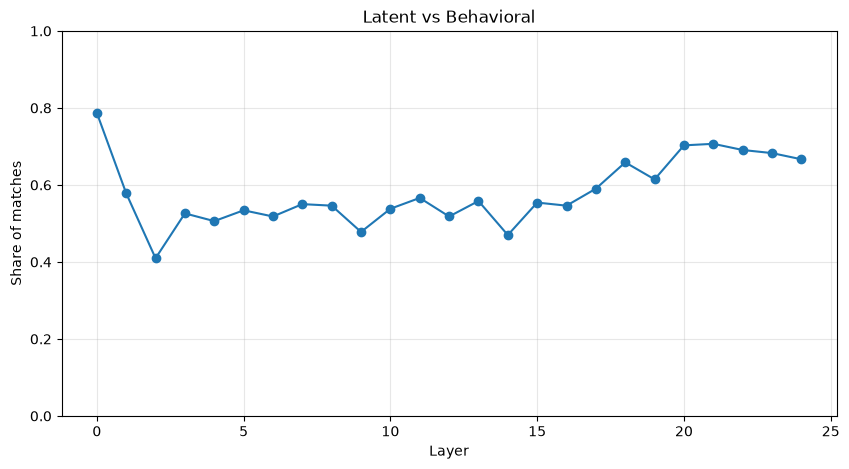

In [15]:
latent_vs_behavioral = (
    test_df
    .dropna(subset=["behavioral_score"])
    .groupby("layer")
    .apply(
        lambda x: (
            x["latent_pred"] == x["behavioral_score"].astype(int)
        ).mean()
    )
)

plt.figure(figsize=(10, 5))
plt.plot(
    latent_vs_behavioral.index,
    latent_vs_behavioral.values,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Share of matches")
plt.title("Latent vs Behavioral")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.show()

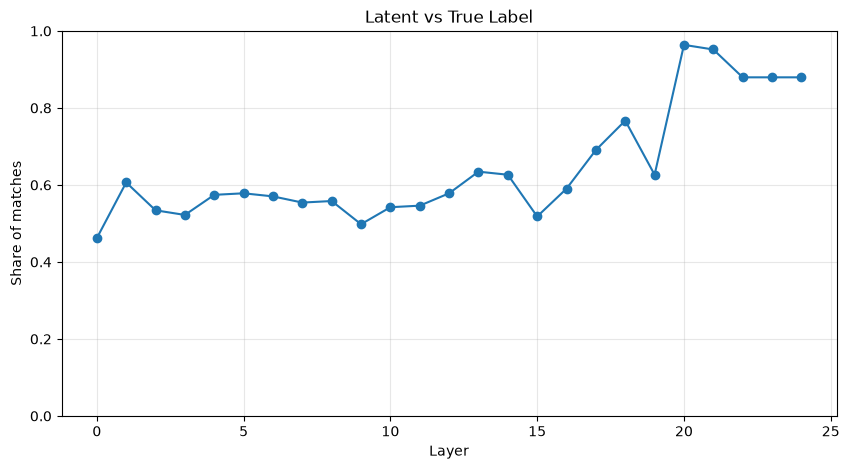

In [16]:
latent_vs_true = (
    test_df
    .groupby("layer")
    .apply(
        lambda x: (
            x["latent_pred"] == x["true_label"]
        ).mean()
    )
)

plt.figure(figsize=(10, 5))
plt.plot(
    latent_vs_true.index,
    latent_vs_true.values,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Share of matches")
plt.title("Latent vs True Label")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.show()

In [17]:
behavioral_df = (
    test_df[
        ["sample_idx", "true_label", "behavioral_score"]
    ]
    .drop_duplicates("sample_idx")
    .dropna(subset=["behavioral_score"])
)

behavioral_vs_true = (
    behavioral_df["behavioral_score"].astype(int)
    == behavioral_df["true_label"]
).mean()

print("Behavioral vs true:", behavioral_vs_true)

Behavioral vs true: 0.6666666666666666


In [18]:
BEST_LAYER = 20

df = checkpoint1_scores.query(
    "split == 'test' and layer == @BEST_LAYER"
).copy()

df["latent_pred"] = (
    df["latent_score"] > 0.5
).astype(int)

latent_correct = (
    df["latent_pred"] == df["true_label"]
)

behavioral_correct = (
    df["behavioral_score"] == df["true_label"]
)

df["case"] = np.select(
    [
        latent_correct & behavioral_correct,
        latent_correct & ~behavioral_correct,
        ~latent_correct & behavioral_correct,
        ~latent_correct & ~behavioral_correct,
    ],
    [
        "Both correct",
        "Latent only correct",
        "Behavioral only correct",
        "Both wrong",
    ], default = None
)

summary = (
    df["case"]
    .value_counts()
    .rename("count")
    .to_frame()
)

summary["share"] = summary["count"] / len(df)

summary

,count,share
case,,
Both correct,166,0.666667
Latent only correct,74,0.297189
Both wrong,9,0.036145
